In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#this script allows plotting of the relevant abundance of proteins as a volcano plot against their p value

#pass the list of conditions you want to plot as a list

#it is possible to highlight certain groups of genes in different colours depending on your preferences

def create_volcano_plots_all_conditions(input_file, output_dir, conditions, magenta_genes, green_genes, black_genes, jitter_strength=0.01, font_size=16):
    os.makedirs(output_dir, exist_ok=True)
    data = pd.read_csv(input_file)

    # Clean column names just in case
    data.columns = data.columns.str.strip()

    # Create a new column with list of genes per row
    data['Gene_list'] = data['Gene'].fillna('').apply(lambda x: [g.strip() for g in x.split(';') if g.strip()])

    for condition in conditions:
        abundance_col = condition
        logp_col = f"{condition}-LogP"

        if abundance_col not in data.columns or logp_col not in data.columns:
            print(f"Skipping {condition} — missing columns")
            continue

        data_copy = data.copy()
        data_copy['abundance'] = data_copy[abundance_col]
        data_copy['logP'] = data_copy[logp_col]
        data_copy['abundance'] += np.random.normal(0, jitter_strength, size=len(data_copy))

        plt.figure(figsize=(9, 7))
        ax = sns.scatterplot(x='abundance', y='logP', data=data_copy, color='#A9A9A9', s=160)

        # Highlight selected gene sets with exact matching
        gene_sets = [
            ('magenta', magenta_genes, 'SAGA'),
            ('#90EE90', green_genes, 'ATAC'),
            ('black', black_genes, 'TFIID')
        ]

        for color, highlight_genes, label in gene_sets:
            highlight_set = set(highlight_genes)
            subset = data_copy[data_copy['Gene_list'].apply(lambda genes: any(g in highlight_set for g in genes))]
            sns.scatterplot(x='abundance', y='logP', data=subset, color=color, s=160, ax=ax, label=label)

        ax.set_xlabel('Log2 fold change', fontsize=font_size)
        ax.set_ylabel('-log10(p-value)', fontsize=font_size)
        ax.set_title(condition, fontsize=font_size + 2)
        ax.set_xlim(-2.25, 2.25)
        ax.set_ylim(-0.5, 7)
        ax.tick_params(axis='both', which='major', labelsize=font_size - 2)

        # Threshold lines
        ax.axhline(y=1.3, color='black', linestyle='--', linewidth=1)   # p = 0.05
        ax.axvline(x=0.3, color='black', linestyle='--', linewidth=1)   
        ax.axvline(x=-0.3, color='black', linestyle='--', linewidth=1)  

        if ax.get_legend():
            ax.legend(fontsize=font_size - 2)

        plt.tight_layout()
        plot_basename = condition.replace('-', '_')
        plt.savefig(f'{output_dir}/saga_no_label_saga_atac_tfiid_volcano_{plot_basename}.png', dpi=300, bbox_inches='tight')
        plt.savefig(f'{output_dir}/saga_no_label_saga_atac_tfiid_volcano_{plot_basename}.pdf', dpi=300, bbox_inches='tight')
        plt.show()


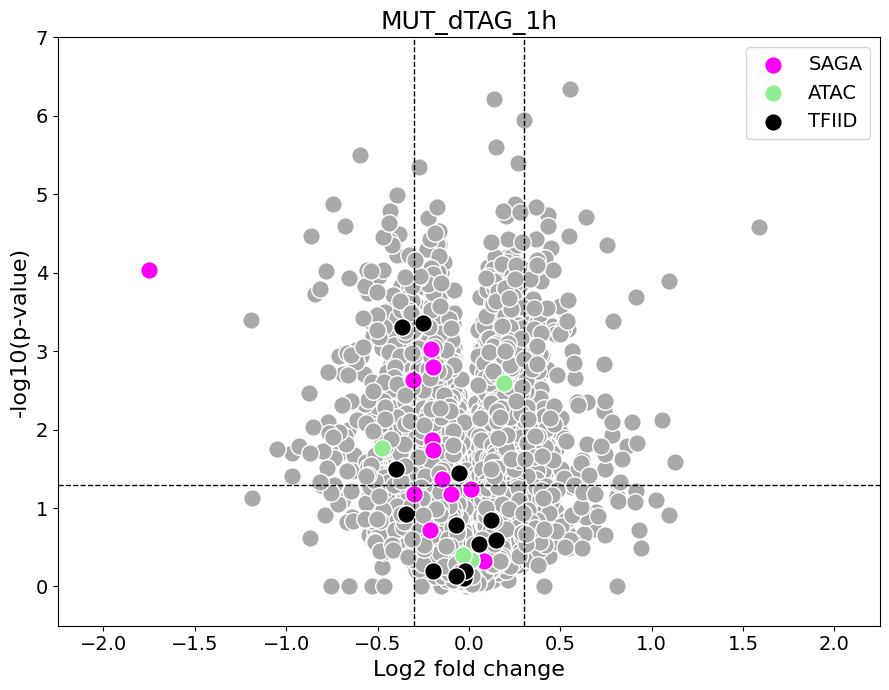

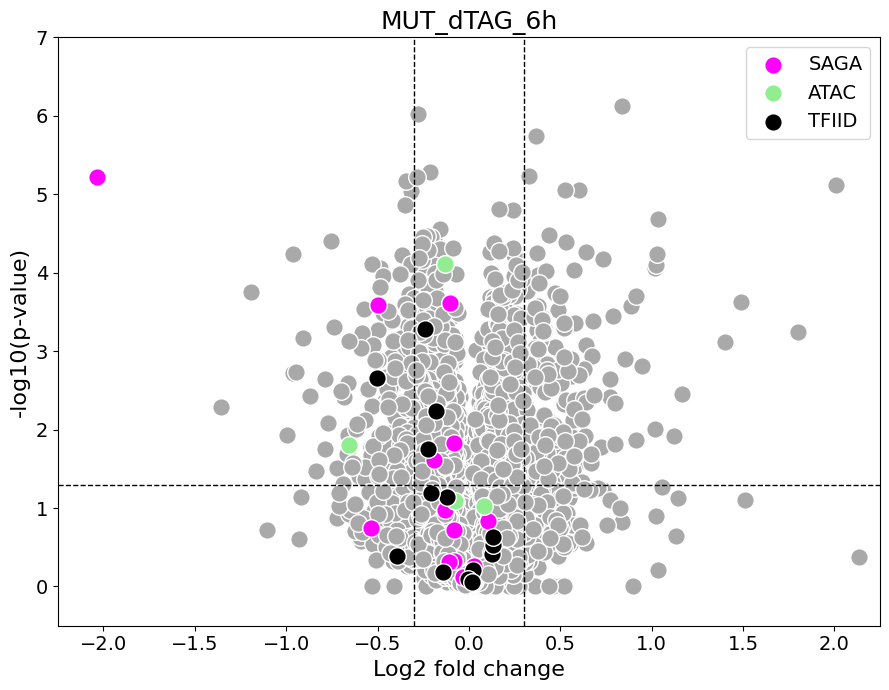

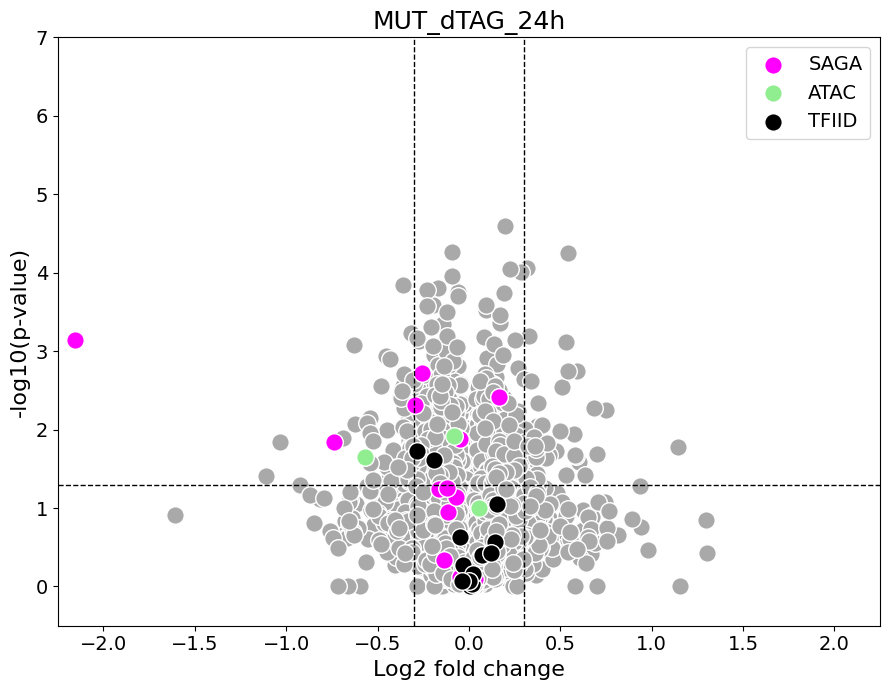

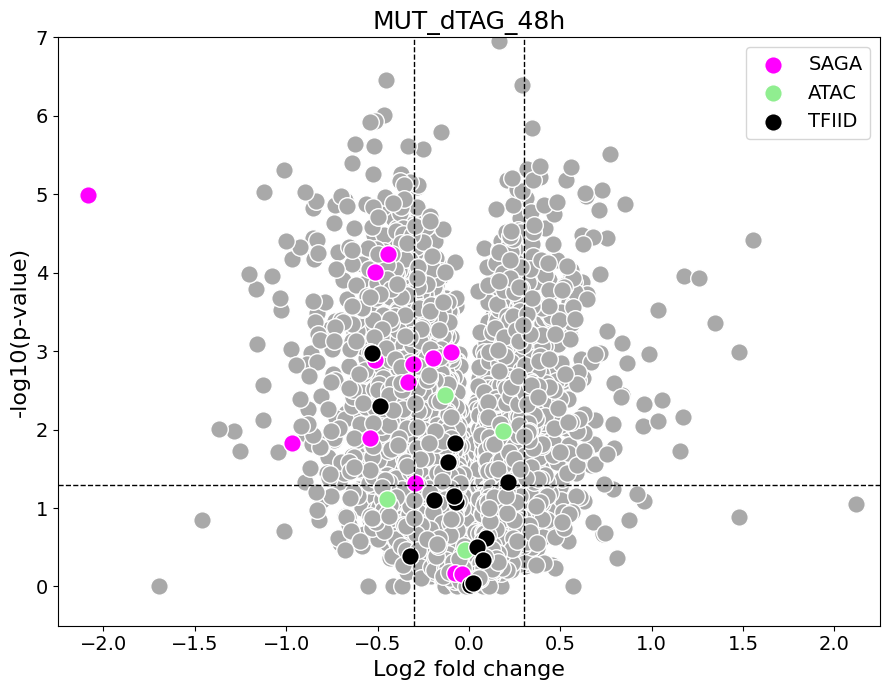

In [22]:

# Define input and output directories
input_file = "input_for_volcano_plot_merged_reps.csv"
output_dir = "/volcano_plots/"

conditions = [
    'MUT_dTAG_1h', 'MUT_dTAG_6h', 'MUT_dTAG_24h', 'MUT_dTAG_48h']

magenta_genes = ['TAF5L', 'TAF6L', 'TADA1', 'SUPT3H', 'SUPT7L', 'SUPT20H', 'TAF9B', 'TAF10', 'TAF12', 'KAT2A', 'SGF29', 'TADA3', 'TADA2B', 'ATXN7', 'ATXN7L3', 'ENY2', 'USP22', 'SF3B3', 'SF3B5', 'TRRAP']
green_genes = ['YEATS2', 'ZZZ3', 'ATAC2', 'MBIP', 'WDR5', 'DR1']
black_genes = ['TBP', 'TAF1', 'TAF2', 'TAF3', 'TAF4', 'TAF5', 'TAF6', 'TAF7', 'TAF8', 'TAF9', 'TAF10', 'TAF11', 'TAF12', 'TAF13']

create_volcano_plots_all_conditions(
    input_file, output_dir, conditions,
    magenta_genes, green_genes, black_genes
)

